In [1]:
import numpy as np
import h5py
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# data_dir = Path('../Data/high_density_brain/')

results_dir = Path('/home/joshua/Documents/Results')
ts_dir = results_dir/"RAW_time_series_aries.h5"
res_dir = results_dir/"RAW_results_aries.h5"

In [3]:
res_dir.is_file()

True

In [4]:
with h5py.File(ts_dir, "r") as f:
    # Print all root level object names (aka keys) 
    # these can be group or dataset names 
    print("Keys: %s" % f.keys())
    # get first object name/key; may or may NOT be a group
    a_group_key = list(f.keys())[0]

    # # get the object type for a_group_key: usually group or dataset
    print(type(f[a_group_key])) 

    # # If a_group_key is a group name, 
    # # this gets the object names in the group and returns as a list
    # data = list(f[a_group_key])

    # # If a_group_key is a dataset name, 
    # # this gets the dataset values and returns as a list
    # data = list(f[a_group_key])
    # # preferred methods to get dataset values:
    # ds_obj = f[a_group_key]      # returns as a h5py dataset object
    sim_times = f[a_group_key][()]  # returns as a numpy array

with h5py.File(res_dir, "r") as f:
    theKey=list(f.keys())[0]
    res = f[theKey][()]

Keys: <KeysViewHDF5 ['RAW_time_series']>
<class 'h5py._hl.dataset.Dataset'>


In [5]:
res.shape

(1000, 6, 16636, 1)

In [6]:
sim_times=res[0][0]
y2=res[:,2,:,0]
y4=res[:,4,:,0]

a2=0.8
a4=0.25

y=a2*y2-a4*y4

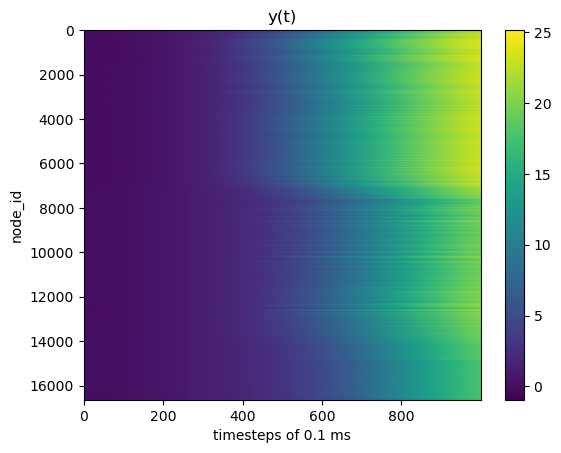

<Figure size 640x480 with 0 Axes>

In [16]:
y_all_nodes=results_dir/"y(t)_all_nodes.png"

plt.figure()
plt.imshow(y.T,aspect='auto')
plt.title('y(t)')
plt.xlabel('timesteps of 0.1 ms')
plt.ylabel('node_id')
plt.colorbar()
plt.savefig(y_all_nodes)
plt.show()
plt.clf()

In [18]:
y_first_node=results_dir/"y(t)_first_node.png"
plt.plot(y[:,0])
plt.savefig(y_first_node)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

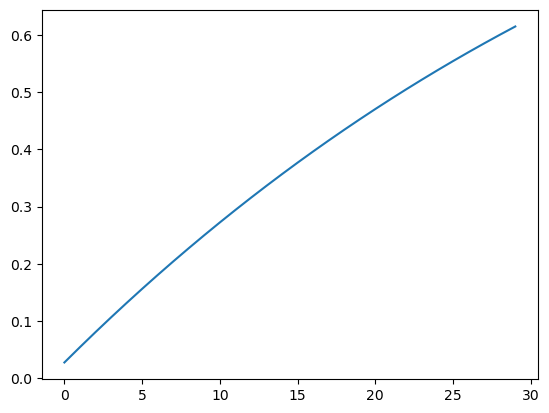

In [9]:
y4_30_node=results_dir/"y4(t)_30th_node.png"
plt.plot(y4[:30,0])
plt.savefig(y4_30_node)
plt.show()
plt.clf()

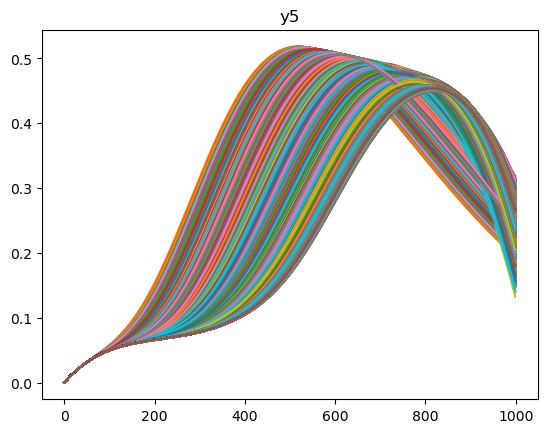

In [10]:
y5_all_nodes=results_dir/"y5(t)_all_nodes.png"
plt.plot(res[:,5,:,0])
plt.title('y5')
plt.savefig(y5_all_nodes)
plt.show()
plt.clf()

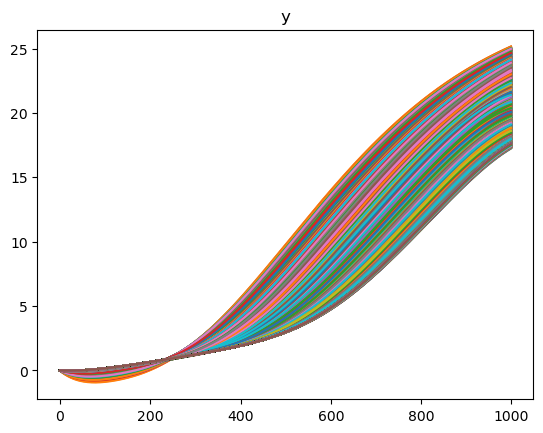

In [11]:
y_all_nodes_linear=results_dir/'y(t)_all_nodes_linear.png'
plt.plot(y)
plt.title('y')
plt.savefig(y_all_nodes_linear)
plt.show()
plt.clf()